In [75]:
import ROOT
import numpy as np

In [76]:
file_path = "../root/out_bigsim.root"

file = ROOT.TFile.Open(file_path)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


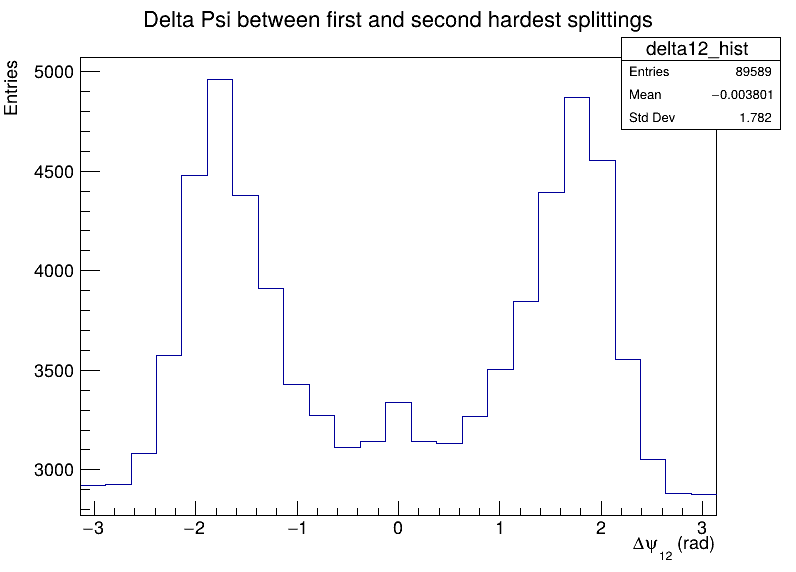

In [77]:
hist_psi12 = file.Get("delta_psi12")
canvas = ROOT.TCanvas("canvas", "Canvas for delta_psi12", 800, 600)
hist_psi12.Draw("HIST")
canvas.Draw()

In [78]:
#Get average value of histogram integrated
integral = hist_psi12.Integral()
print(f"Integral of delta_psi12 histogram: {integral}")

#Get y mean value of histogram
y = 0
for bin in range(1, hist_psi12.GetNbinsX() + 1):
    bin_center = hist_psi12.GetBinCenter(bin)
    bin_content = hist_psi12.GetBinContent(bin)
    y += bin_content

y_mean = y / hist_psi12.GetNbinsX()
print(f"Y mean value of delta_psi12 histogram: {y_mean}")
print(f"Average Y mean / Integral: {y_mean / integral}")

Integral of delta_psi12 histogram: 89589.0
Y mean value of delta_psi12 histogram: 3583.56
Average Y mean / Integral: 0.04


Fitted parameters: A = 3557.4958299453074, B = -743.6688118682594, C = nan
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      651.604
NDf                       =           23
Edm                       =  1.30184e-22
NCalls                    =           34
p0                        =       3557.5   +/-   11.9289     
p1                        =     -743.669   +/-   17.1028     


Error in <TFormula::GetParameter>: wrong index used - use GetParameter(name)


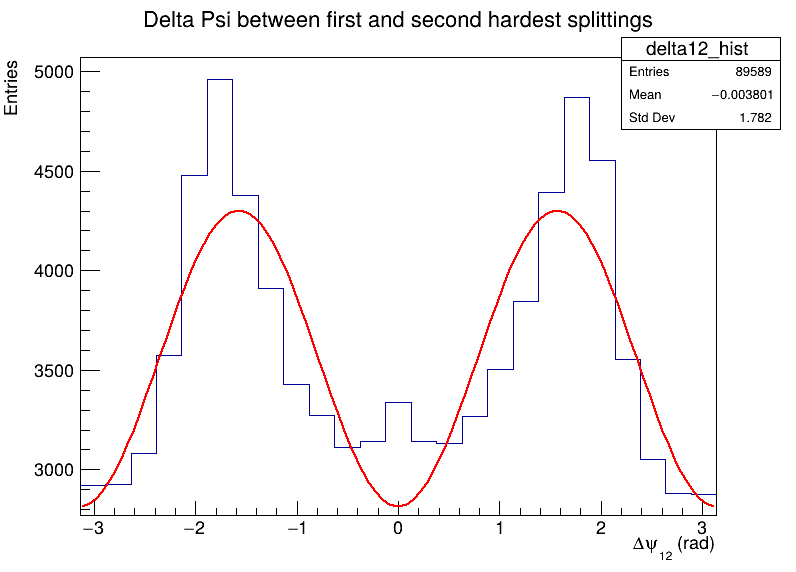

In [79]:
#f(x) = A (1 + B*cos(2x))
function = ROOT.TF1("function", "[0] + [1]*cos(2*x)", -np.pi, np.pi)

hist_psi12.Fit("function", "")
A = function.GetParameter(0)
B = function.GetParameter(1)
C = function.GetParameter(2)
print(f"Fitted parameters: A = {A}, B = {B}, C = {C}")

#Draw fitted function on the same canvas
function.SetLineColor(ROOT.kRed)
function.Draw("SAME")
canvas.Draw()

In [80]:
file_path = "../root/out_ACFC9020-1195-734D-926E-2DD16742E491.root"

file = ROOT.TFile.Open(file_path)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_EEEC


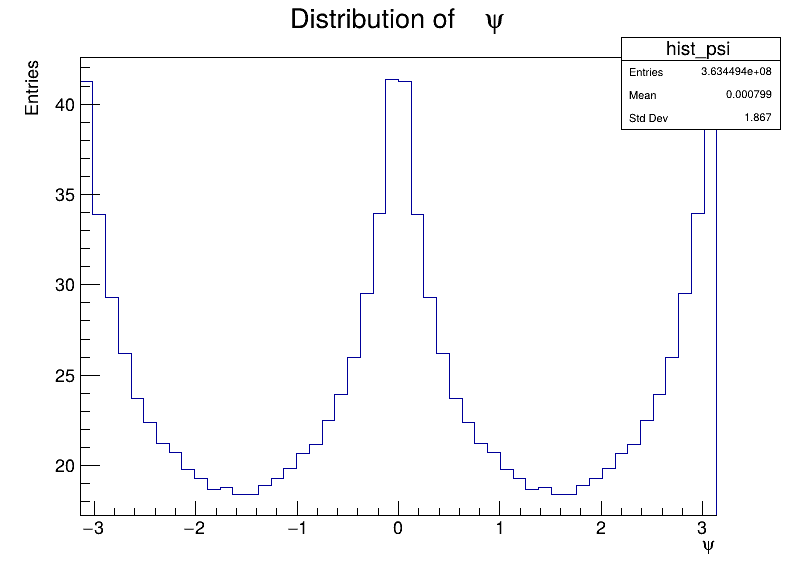

In [81]:
hist_EEEC = file.Get("hist_psi_final")
canvas_EEEC = ROOT.TCanvas("canvas_EEEC", "Canvas for hist_psi_final", 800, 600)
hist_EEEC.Draw("HIST")
canvas_EEEC.Draw()

In [82]:
#Get average value of histogram integrated
integral = hist_EEEC.Integral()
print(f"Integral of delta_psi12 histogram: {integral}")

#Get y mean value of histogram
y = 0
for bin in range(1, hist_EEEC.GetNbinsX() + 1):
    bin_center = hist_EEEC.GetBinCenter(bin)
    bin_content = hist_EEEC.GetBinContent(bin)
    y += bin_content

y_mean = y / hist_EEEC.GetNbinsX()
print(f"Y mean value of delta_psi12 histogram: {y_mean}")
print(f"Average Y mean / Integral: {y_mean / integral}")

Integral of delta_psi12 histogram: 1218.4832191467285
Y mean value of delta_psi12 histogram: 24.36966438293457
Average Y mean / Integral: 0.02


Fitted parameters: A = 19.263022082082674, B = 1.2931337774579346, C = 2.7218259782194716, D = nan
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      2110.66
NDf                       =           47
Edm                       =  3.87786e-06
NCalls                    =          238
p0                        =       19.263   +/-   0.0357702   
p1                        =      1.29313   +/-   0.0395892   
p2                        =      2.72183   +/-   0.032302     	 (limited)


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Error in <TFormula::GetParameter>: wrong index used - use GetParameter(name)


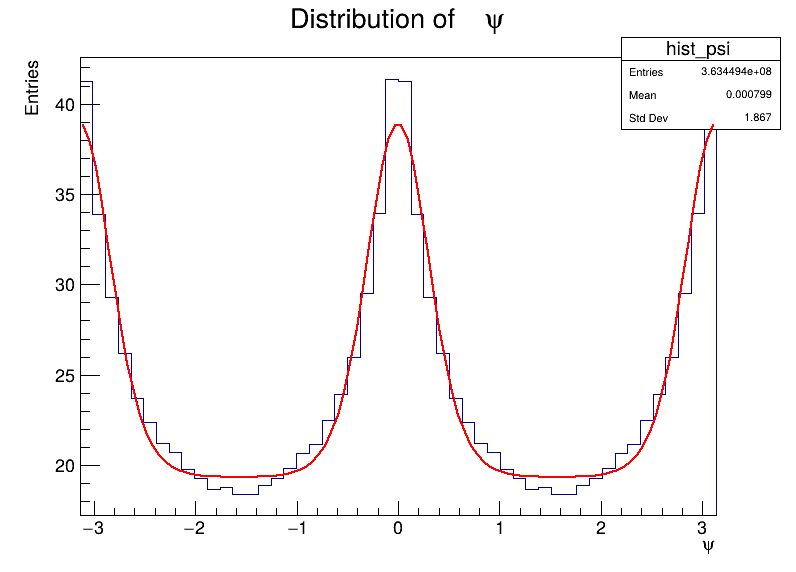

In [83]:
#f(x) = A (1 + B*cos(2x))
function = ROOT.TF1("function", "[0]+[1]*exp([2]*cos(2*x))", -np.pi, np.pi)
#function.SetParameters(hist_EEEC.GetMaximum(), 0.0)
function.SetParLimits(2, 1 ,10) 

hist_EEEC.Fit("function", "R")
A = function.GetParameter(0)
B = function.GetParameter(1)
C = function.GetParameter(2)
D = function.GetParameter(3)
print(f"Fitted parameters: A = {A}, B = {B}, C = {C}, D = {D}")

#Draw fitted function on the same canvas
function.SetLineColor(ROOT.kRed)
function.Draw("SAME")
canvas_EEEC.Draw()
